In [16]:
from jax.lax import integer_pow_p
import jax 

import numpy as np

import jax.numpy as jnp
import jax.random as jrandom
from jax import lax

from probjax.core.stochastic_inverses.inverse_factorys import inverse_matrix_vector_multiplication
from probjax.distributions import MultivariateNormal

from sbi.analysis import pairplot

In [17]:
x_dim = 5
theta_dim = 3

prior = MultivariateNormal(jnp.zeros(theta_dim), jnp.eye(theta_dim))
A = jrandom.normal(jrandom.PRNGKey(0), (x_dim,theta_dim))
likelihood_cov = jnp.eye(x_dim)*0.01

def simulator(key, theta):
    x_o = A@theta 
    noise = jnp.linalg.cholesky(likelihood_cov)@jrandom.normal(key, (x_dim,))
    out = jax.nn.sigmoid(x_o) + noise
    return out

def simulator2(key, theta):
    x_o = A@theta 
    noise = jnp.linalg.cholesky(likelihood_cov)@jrandom.normal(key, (x_dim,))
    out = jax.nn.sigmoid(x_o) + noise
    return out, noise


In [18]:
theta_o = jrandom.normal(jrandom.PRNGKey(42), (theta_dim,))
x_o = simulator(jrandom.PRNGKey(43), theta_o)
x_o

Array([0.16508788, 0.8040741 , 0.8554948 , 0.12810728, 0.9891596 ],      dtype=float32)

In [19]:
xs, noise = jax.vmap(simulator2, in_axes=(0, 0))(jrandom.split(jrandom.PRNGKey(0), 1000000), prior.sample(jrandom.PRNGKey(1),(1000000,)))
mask = jnp.abs(xs-x_o).mean(-1) < 0.1
dist_noise = noise[mask]

In [20]:
noise_lower = - x_o.clip(min=0) - x_o.clip(max=0)
noise_upper = (1 - x_o).clip(min=0) + (1 - x_o).clip(max=0)

In [21]:
sampling_fn = inverse_matrix_vector_multiplication(A)

def inverse_simulator(key, x):
    key1, key2 = jrandom.split(key, 2)
    noise = jrandom.choice(key1,dist_noise)
    y = x - noise 
    x_o = jax.scipy.special.logit(y)
    theta = sampling_fn(key2, x_o)
    return theta

batched_inverse_simulator = jax.vmap(inverse_simulator, in_axes=(0, None), out_axes=0)

In [22]:
theta = inverse_simulator(jrandom.PRNGKey(42), x_o)

In [23]:
simulator(jrandom.PRNGKey(45), theta)

Array([0.13042778, 0.68437606, 0.8936725 , 0.17281328, 0.82711214],      dtype=float32)

In [24]:
thetas = batched_inverse_simulator(jrandom.split(jrandom.PRNGKey(0), 10000), x_o)

thetas = thetas[jnp.isfinite(thetas).all(-1)]

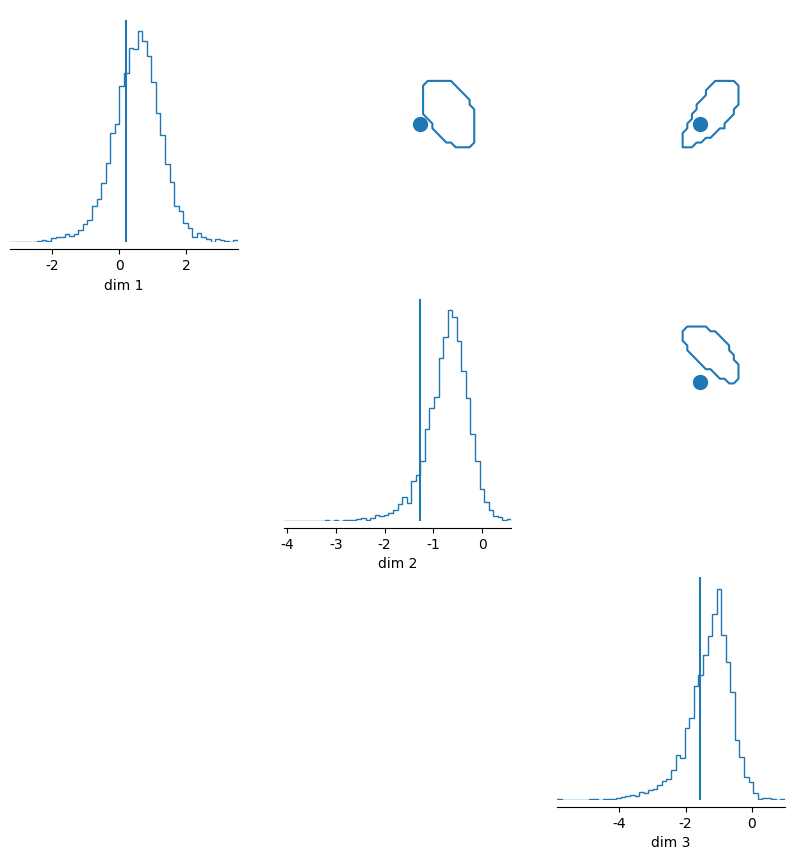

In [25]:
_ = pairplot([np.array(thetas)], upper="contour", points=np.array(theta_o))

In [400]:
xs_predictive = jax.vmap(simulator, in_axes=(0, 0))(jrandom.split(jrandom.PRNGKey(0), thetas.shape[0]), thetas)

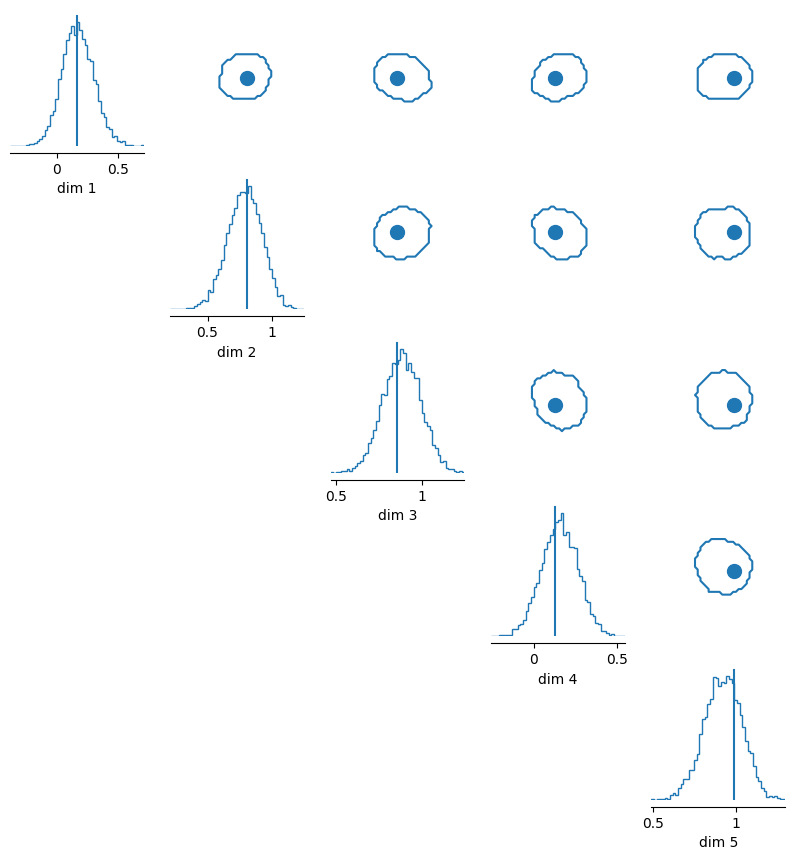

In [401]:
_ = pairplot([np.array(xs_predictive)], upper="contour", points=np.array(x_o))